In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

DATI_TB = Path("..") / "dati_tensorboard"
SEMI = [0, 1, 2, 3, 4]
EPOCA_SVOLTA = 170  # oltre questa epoca l'AUC smette di saturare e comincia a scendere


def carica_curve(sottocartella, semi=SEMI):
    "Legge i json esportati da tensorboard per ogni seme: [wall_time, step, value]."
    curve = {}
    for i in semi:
        with open(DATI_TB / sottocartella / f"riproduzione_2.6M_deep_low_seme{i}.json") as f:
            dati = json.load(f)
        epoche = [riga[1] for riga in dati]
        valori = [riga[2] for riga in dati]
        curve[i] = (epoche, valori)
    return curve


def grafico_curve(curve, ylabel, titolo, epoca_svolta=EPOCA_SVOLTA):
    fig, ax = plt.subplots(figsize=(8, 5))

    for i, (epoche, valori) in curve.items():
        ax.plot(epoche, valori, linewidth=1.3, label=f"seme {i}")

    if epoca_svolta is not None:
        ax.axvline(epoca_svolta, color="black", linestyle="--", linewidth=1.2,
                   label=f"epoca {epoca_svolta}")

    ax.set_xlabel("epoca")
    ax.set_ylabel(ylabel)
    ax.set_title(titolo)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()

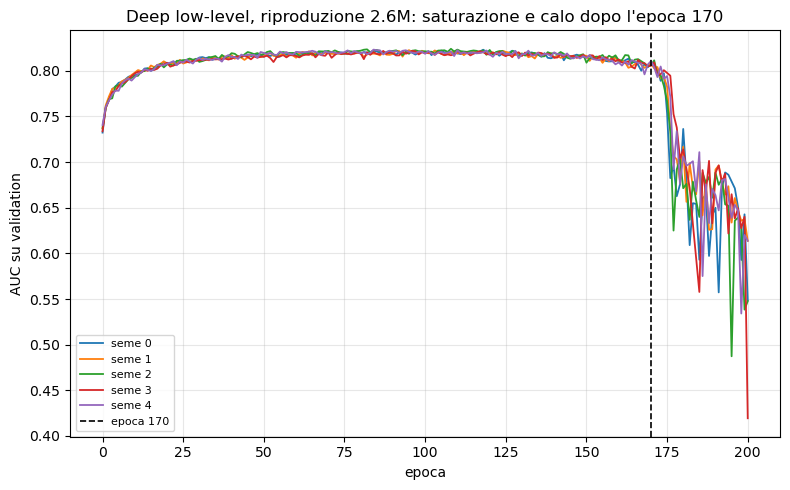

In [2]:
# AUC su validation
curve_auc = carica_curve("AUC_2.6M")
grafico_curve(curve_auc, "AUC su validation",
              "Deep low-level, riproduzione 2.6M: saturazione e calo dopo l'epoca 170")

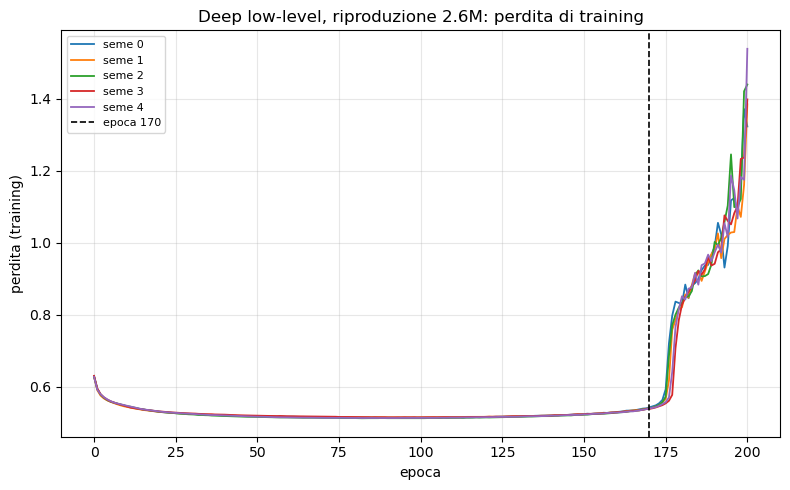

In [3]:
# perdita di training
curve_perdita_train = carica_curve("Perdita_2.6M")
grafico_curve(curve_perdita_train, "perdita (training)",
              "Deep low-level, riproduzione 2.6M: perdita di training")

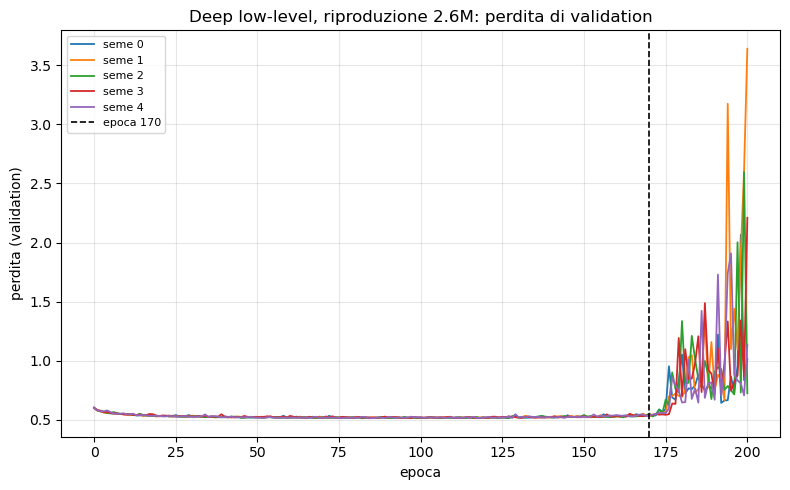

In [4]:
# perdita di validation
curve_perdita_val = carica_curve("val_perdita_2.6M")
grafico_curve(curve_perdita_val, "perdita (validation)",
              "Deep low-level, riproduzione 2.6M: perdita di validation")

In [5]:
# riproduzione completa: deep e shallow, tre feature set, grafici accoppiati
MODELLI = ["shallow", "deep"]
FEATURE_SETS = ["low", "high", "complete"]


def carica_curva_riproduzione(sottocartella, modello, feature_set, seme=0):
    percorso = DATI_TB / sottocartella / f"riproduzione_{modello}_{feature_set}_seme{seme}.json"
    with open(percorso) as f:
        dati = json.load(f)
    epoche = [riga[1] for riga in dati]
    valori = [riga[2] for riga in dati]
    return epoche, valori


def grafico_accoppiato(sottocartella, ylabel, titolo):
    "Un grafico per la rete shallow e uno per la rete profonda, affiancati."
    fig, assi = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    for ax, modello, sottotitolo in zip(assi, MODELLI, ["rete shallow", "rete profonda"]):
        for fs in FEATURE_SETS:
            epoche, valori = carica_curva_riproduzione(sottocartella, modello, fs)
            ax.plot(epoche, valori, linewidth=1.3, label=fs)
        ax.set_xlabel("epoca")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)
        ax.set_title(sottotitolo)

    assi[0].set_ylabel(ylabel)
    fig.suptitle(titolo)
    fig.tight_layout()
    plt.show()

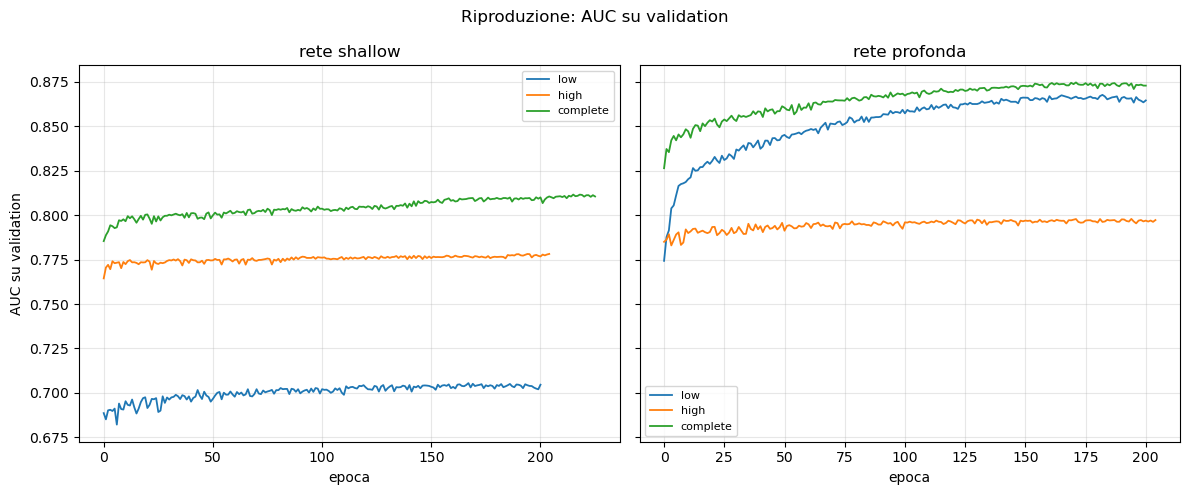

In [6]:
grafico_accoppiato("riproduzione_AUC", "AUC su validation",
                    "Riproduzione: AUC su validation")

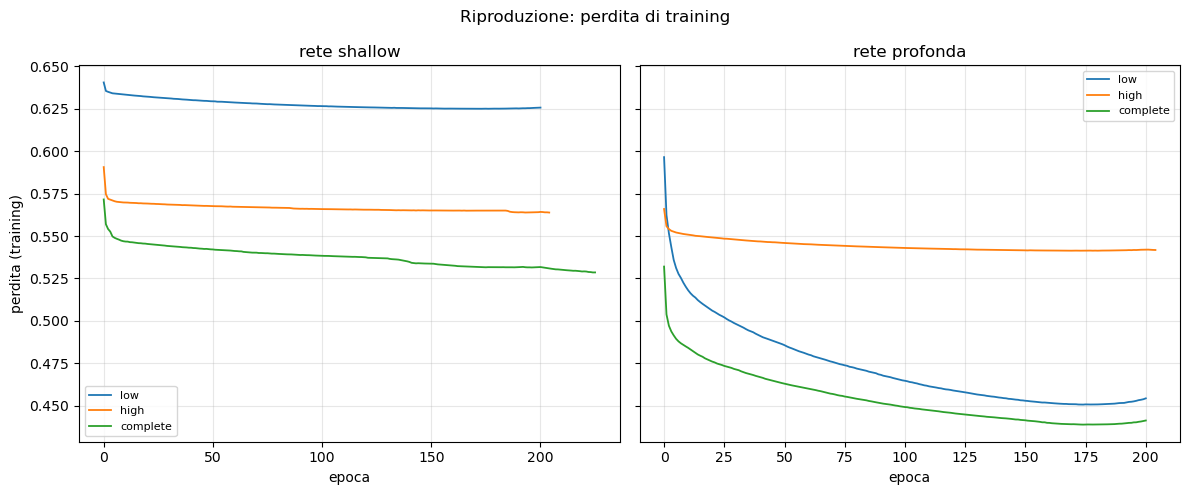

In [7]:
grafico_accoppiato("riproduzione_perdita_train", "perdita (training)",
                    "Riproduzione: perdita di training")

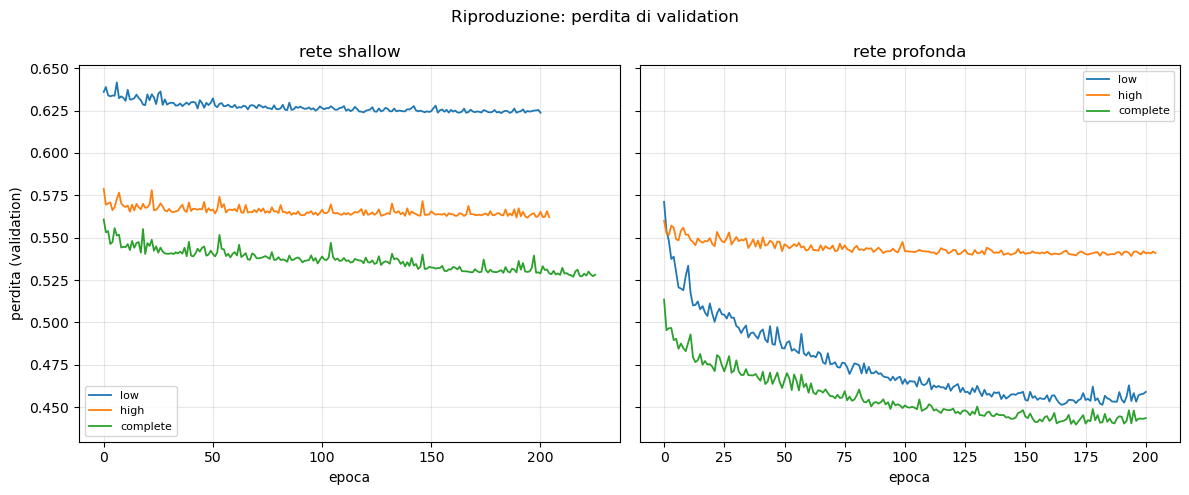

In [8]:
grafico_accoppiato("riproduzione_perdita_validation", "perdita (validation)",
                    "Riproduzione: perdita di validation")